In [60]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import random
random.seed(42)
g=torch.Generator().manual_seed(2176)
import torch.nn.functional as F

words=open('names.txt','r').read().splitlines()

#encoding
itos={i+1:ch for i,ch in enumerate(list("abcdefghijklmnopqrstuvwxyz"))}
itos[0]='.'
stoi={ch:i for i,ch in itos.items()}

In [61]:
#hyperparameters
block_size=8
vector_dim=24
hidden_layer_size=128
batch_size=32
squash =2

In [62]:
#building the dataset
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
train_words=words[:n1]
dev_words=words[n1:n2]
test_words=words[n2:]
Xtr=[]
Ytr=[]
Xdev=[]
Ydev=[]
Xte=[]
Yte=[]

for word in train_words:
    context=[0]*block_size
    for ch in word+".":
        Xtr.append(context)
        Ytr.append(stoi[ch])
        context=context[1:]+[stoi[ch]]
for word in dev_words:
    context=[0]*block_size
    for ch in word+".":
        Xdev.append(context)
        Ydev.append(stoi[ch])
        context=context[1:]+[stoi[ch]]
for word in test_words:
    context=[0]*block_size
    for ch in word+".":
        Xte.append(context)
        Yte.append(stoi[ch])
        context=context[1:]+[stoi[ch]]

Xtr=torch.tensor(Xtr)
Ytr=torch.tensor(Ytr)

Xte=torch.tensor(Xte)
Yte=torch.tensor(Yte)

Xdev=torch.tensor(Xdev)
Ydev=torch.tensor(Ydev)


In [63]:
class Linear:

    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in, fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None
        

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out+= self.bias
        return self.out
    
    def parameters(self):
        return [self.weight]+([] if self.bias is None else [self.bias])
    
class BatchNormld:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        #trainable parameters
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        #buffers
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)

    def __call__(self,x):
        
        if self.training:
            if x.ndim==2:
                dim=0
            elif x.ndim==3:
                dim=(0,1)
            xmean=x.mean(dim, keepdim=True)#batch mean
            xvar=x.var(dim, keepdim=True)#batch variance
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)
        self.out=self.gamma*xhat+self.beta

        #update the buffers
        if self.training:
            self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
            self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar

        return self.out
    
    def parameters(self):
        return [self.gamma,self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
class Embedding:

    def __init__(self,vocab_size,vector_dim):
        self.weight=torch.randn((vocab_size,vector_dim))

    def __call__(self,IX):
        self.out=self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self,n):
        self.n=n #n is the number of consecutive elements you want to squash

    def __call__(self,x):
        B, T, C=x.shape
        x=x.view(B,T//self.n,self.n*C)
        if x.shape[1]==1:
            x=x.squeeze(1)#if the function flattens all the elements then return a 2D vector rather than a 3D one
        self.out=x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:

    def __init__(self,layers):
        self.layers=layers


    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        self.out=x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    





In [64]:

#the layers
model=Sequential([Embedding(27,vector_dim),
                  FlattenConsecutive(squash),Linear(vector_dim*squash, hidden_layer_size,bias=False), BatchNormld(hidden_layer_size),Tanh(),
                  FlattenConsecutive(squash),Linear(hidden_layer_size*squash, hidden_layer_size,bias=False), BatchNormld(hidden_layer_size),Tanh(),
                  FlattenConsecutive(squash),Linear(hidden_layer_size*squash, hidden_layer_size,bias=False), BatchNormld(hidden_layer_size),Tanh(),
                  Linear(hidden_layer_size,27),])  
#parameter init
with torch.no_grad():
    model.layers[-1].weight*=0.1
    model.layers[-1].bias*=0

parameters=model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

76579


In [65]:
with torch.no_grad():
    ix= torch.randint(0,Xtr.shape[0],(4,))
    Xb, Yb= Xtr[ix], Ytr[ix]
    logits=model(Xb)
    print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0, 13,  1, 18,  9, 20,  1],
        [ 0,  0,  0,  3,  1, 13,  9, 12],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  8, 15]])

In [66]:
for layer in model.layers:
    print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNormld : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNormld : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNormld : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In this flattening layer for wavenet we dont want a long 80 length array for 8 characters of context. Instead of squashing 8 characters at once we want to squash 2 characters at a time so we want the out to have shape (4,4,20). Then we would like to multilpy this with the linear layer which now would have 20 inputs rather than 80. By broadcasting this linear layer would be applied on each of the 4 bigrams of 20 inputs parallely. So we need to change the input of the linear layer and the flatten layer.To do this instead of the flatten layer we used we could use something like the following on our (4,8,10) vectors

In [67]:
e=torch.randn(4,8,10)
explicit=torch.cat([e[:,::2,:],e[:,1::2,:]],dim=2)

In [68]:
(e.view(4,4,20) == explicit).all()

tensor(True)

In [69]:
max_steps=200000
batch_size=32
lossi=[]

for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb, Yb=Xtr[ix],Ytr[ix]

    #
    logits=model(Xb)
    loss=F.cross_entropy(logits,Yb)

    for p in parameters:
        p.grad=None
    loss.backward()

    lr=0.1 if i<150000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad
    
    if i%10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item() :.4f}') 
    lossi.append(loss.log10().item())


      0/ 200000: 3.2906
  10000/ 200000: 1.9405
  20000/ 200000: 1.8629
  30000/ 200000: 2.2006
  40000/ 200000: 2.0825
  50000/ 200000: 2.0514
  60000/ 200000: 1.8800
  70000/ 200000: 1.8597
  80000/ 200000: 2.3008
  90000/ 200000: 2.2202
 100000/ 200000: 1.9720
 110000/ 200000: 1.9930
 120000/ 200000: 1.8165
 130000/ 200000: 1.8530
 140000/ 200000: 2.0328
 150000/ 200000: 1.9698
 160000/ 200000: 2.3702
 170000/ 200000: 1.5110
 180000/ 200000: 1.8965
 190000/ 200000: 1.9700


To cancel out the noise we can take moving average

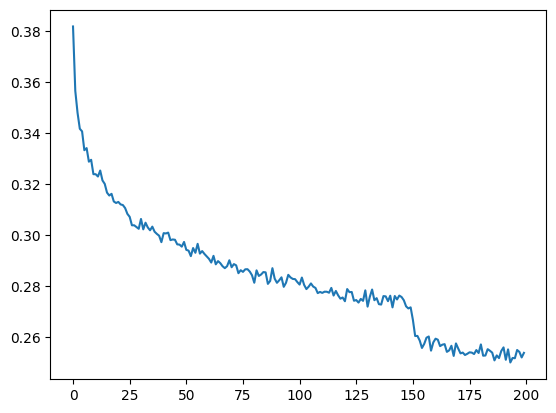

In [70]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [71]:
for layer in model.layers:
    layer.training=False

In [72]:
@torch.no_grad()
def split_loss(split):
    x,y = { 
        'train':(Xtr, Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte, Yte),
    }[split]
    logits=model(x)
    loss=F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7684822082519531
val 1.9877350330352783


In [73]:
for _ in range(20):
    out=[]
    context =[0]*block_size
    while True:
        logits=model(torch.tensor([context]))
        probs=F.softmax(logits,dim=1)

        ix=torch.multinomial(probs, num_samples=1).item()

        context=context[1:]+[ix]
        out.append(ix)

        if ix==0:
            break

    print (''.join(itos[i] for i in out))

barta.
xiniti.
mikia.
maira.
bricelitra.
deavri.
miyamarie.
tvisten.
atricia.
dejo.
arlins.
breylen.
arzjay.
aylle.
rowan.
mangbel.
taxx.
sherrie.
mataulyn.
marc.


In our model our entire context's information is squashed together in a single step. What we would like to do instead is to squash it step by step( 2 at a time). This is a wavenet. We do that in a tree like hierarchical manner.

The matrix multiplication of torch is powerful and can be used for >2 dimensional arrays.
### Matrix Multiplication in PyTorch
1. ***vector x matrix***: (z) @ (z,y) (z) dimension vector is considered as a row matrix (1,z) and the resulting (1,y) matrices extra dimension is remmoved so the resulting matrix is  (y,).
2. ***matrix x vector***: (y,z) @ (z) similar to above case
3. ***2D matrix x 2D matrix***: works like normal linear algebra
4. ***vector x vector***: dot product
5. ***Batched Matrix Multiplication***: <br>
A.shape=(10,2,3)<br>
B.shape=(10,3,4)<br>
A @ B is like a batch of 10 (2,3) matrices are multiplied with a batch of 10 (3,4) matrices to result (10,2,4). The batch dimension 10 is handled element by element but the inside multiplications are normal matrix multiplications
6. ***Broadcasting Batched Multiplications***:<br>
A.shape=(...,x,y)<br>
B.shape=(...,y,z)<br>
The ... are the batch dimensions which must be equal or broadcastable<br>
After broadcasting the matrix multiplications are down normally element by element.<br>

### Broadcasting Rules.
Compared right to left elements must be equal or one of them 1 or empty. That dimensions are equalled,


### PERFORMANCE LOG
1. context ->8 (22K parameters) train loss=1.92 validation loss=2.027
2. flat--> hierarchical(22K parameters) train=1.941,val=2.029
3. fix bug in batchnorm: train 1.912 val 2.022
4. scale up the network: n_embd 24, n_hidden 128(76K parameters), train 1.769, val 1.993



### BATCHNORM BUG 
Something is wrong with the mean and var functions dimensions.Ohh okay son we were using a more localish mean earlier now we are taking the mean over a broader output. So we expect a slight improvement